# Notebook 06 — Federated Learning with Flower and FedAvg

This notebook implements a privacy-preserving federated learning simulation
for network intrusion detection using four clients and the FedAvg algorithm.

In [2]:
# ============================================================
# VERIFY PYTHON, FLOWER, AND PYTORCH INSTALLATION
# ============================================================

import sys
import flwr as fl
import ray
import torch

print("Python version:", sys.version.split()[0])
print("Flower version:", fl.__version__)
print("Ray version:", ray.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python version: 3.13.14
Flower version: 1.35.0
Ray version: 2.58.0
PyTorch version: 2.13.0+cpu
CUDA available: False


In [3]:
# ============================================================
# LOAD PROCESSED TRAINING AND TEST DATA
# ============================================================

from pathlib import Path
import pandas as pd

# Update these paths only if your notebook is stored elsewhere.
TRAIN_PATH = Path("../data/processed/CICIDS2017_train.csv")
TEST_PATH = Path("../data/processed/CICIDS2017_test.csv")

# Confirm that both processed files exist.
assert TRAIN_PATH.exists(), f"Training file not found: {TRAIN_PATH.resolve()}"
assert TEST_PATH.exists(), f"Test file not found: {TEST_PATH.resolve()}"

# Load the processed datasets created in Notebook 03–05.
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

print("\nFirst five training columns:")
print(train_df.columns[:5].tolist())

print("\nLast five training columns:")
print(train_df.columns[-5:].tolist())

Training data shape: (2016638, 49)
Test data shape: (504160, 49)

First five training columns:
['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Length_of_Fwd_Packets', 'Fwd_Packet_Length_Max']

Last five training columns:
['Active_Max', 'Active_Min', 'Idle_Std', 'Original_Row_ID', 'Label']


In [4]:
# ============================================================
# SEPARATE FEATURES, ENCODE LABELS, AND STANDARDIZE FEATURES
# ============================================================

import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Find the target-label column.
label_candidates = [
    "Label",
    "label",
    "Class",
    "class",
    "Target",
    "target",
]

LABEL_COLUMN = next(
    (
        column
        for column in label_candidates
        if column in train_df.columns
    ),
    None,
)

assert LABEL_COLUMN is not None, (
    "Label column was not found. Check train_df.columns.tolist()."
)

# Confirm train and test files contain the same columns.
assert set(train_df.columns) == set(test_df.columns), (
    "Train and test datasets have different columns."
)

# Separate input features from the target label.
feature_columns = [
    column
    for column in train_df.columns
    if column != LABEL_COLUMN
]

# Encode target labels as integers: 0, 1, 2, ...
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df[LABEL_COLUMN]
).astype(np.int64)

y_test = label_encoder.transform(
    test_df[LABEL_COLUMN]
).astype(np.int64)

# Convert features to numeric arrays.
X_train = train_df[feature_columns].to_numpy(
    dtype=np.float32
)

X_test = test_df[feature_columns].to_numpy(
    dtype=np.float32
)

# Standardize features using training-data statistics only.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(
    np.float32
)

X_test = scaler.transform(X_test).astype(
    np.float32
)

# Store model dimensions.
NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = len(label_encoder.classes_)

print("✅ Step 5 complete: Features and labels are ready.")
print("Label column:", LABEL_COLUMN)
print("Number of input features:", NUM_FEATURES)
print("Number of classes:", NUM_CLASSES)
print("Class labels:", list(label_encoder.classes_))

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

✅ Step 5 complete: Features and labels are ready.
Label column: Label
Number of input features: 48
Number of classes: 15
Class labels: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

X_train shape: (2016638, 48)
y_train shape: (2016638,)
X_test shape: (504160, 48)
y_test shape: (504160,)


In [5]:
# ============================================================
# SPLIT TRAINING DATA INTO FOUR SIMULATED ORGANIZATIONS
# Each client receives a separate, stratified partition.
# ============================================================

from sklearn.model_selection import StratifiedKFold

SEED = 42
NUM_CLIENTS = 4

client_partitions = []

splitter = StratifiedKFold(
    n_splits=NUM_CLIENTS,
    shuffle=True,
    random_state=SEED,
)

for client_id, (_, client_indices) in enumerate(
    splitter.split(X_train, y_train),
    start=1,
):
    X_client = X_train[client_indices]
    y_client = y_train[client_indices]

    client_partitions.append((X_client, y_client))

    print(
        f"Client {client_id}: "
        f"{len(X_client):,} records | "
        f"Class distribution: {np.bincount(y_client)}"
    )

Client 1: 504,160 records | Class distribution: [419012    390  25602   2057  34570   1045   1077   1186      2      7
  18139    644    294      5    130]
Client 2: 504,160 records | Class distribution: [419011    389  25603   2058  34569   1045   1077   1187      3      7
  18138    644    294      4    131]
Client 3: 504,159 records | Class distribution: [419011    389  25603   2057  34569   1046   1077   1186      2      7
  18139    644    294      4    131]
Client 4: 504,159 records | Class distribution: [419011    390  25603   2057  34569   1046   1077   1186      2      8
  18139    643    294      4    130]


In [6]:
# ============================================================
# NON-IID CLIENT PARTITION — LABEL DISTRIBUTION SKEW
# ============================================================

NUM_CLIENTS = 4
NUM_CLASSES = len(np.unique(y_train))

SEED = 42
rng = np.random.default_rng(SEED)

# Client specialization weights
client_preferences = np.ones((NUM_CLIENTS, NUM_CLASSES))

# Client 1: Benign + DoS
client_preferences[0, [0, 2, 3, 4, 5, 6]] = 5.0

# Client 2: Benign + PortScan
client_preferences[1, [0, 10]] = 5.0

# Client 3: Benign + Brute Force
client_preferences[2, [0, 7, 11, 12]] = 5.0

# Client 4: Benign + Web Attacks
client_preferences[3, [0, 12, 13, 14]] = 5.0

# Collect indices belonging to each class
class_indices = {
    class_id: np.flatnonzero(y_train == class_id)
    for class_id in range(NUM_CLASSES)
}

non_iid_client_indices = [[] for _ in range(NUM_CLIENTS)]

# Allocate each class across clients
for class_id, indices in class_indices.items():

    indices = indices.copy()
    rng.shuffle(indices)

    weights = client_preferences[:, class_id]
    probabilities = weights / weights.sum()

    counts = rng.multinomial(len(indices), probabilities)

    start = 0

    for client_id, count in enumerate(counts):
        client_indices = indices[start:start + count]
        non_iid_client_indices[client_id].extend(client_indices.tolist())
        start += count

# Create client datasets
non_iid_client_partitions = []

for client_id in range(NUM_CLIENTS):

    indices = np.array(non_iid_client_indices[client_id])

    rng.shuffle(indices)

    X_client = X_train[indices]
    y_client = y_train[indices]

    non_iid_client_partitions.append((X_client, y_client))

    print(
        f"Client {client_id + 1}: "
        f"{len(X_client):,} records | "
        f"Class distribution: {np.bincount(y_client, minlength=NUM_CLASSES)}"
    )

Client 1: 591,359 records | Class distribution: [419755    393  64008   5091  86553   2620   2686    609      2      4
   9147    322     91      1     77]
Client 2: 498,171 records | Class distribution: [418873    422  12848   1066  17290    568    554    566      3      9
  45506    304    105      3     54]
Client 3: 465,146 records | Class distribution: [418783    386  12689   1040  17084    474    532   2931      2      8
   9021   1635    475      4     82]
Client 4: 461,962 records | Class distribution: [418634    357  12866   1032  17350    520    536    639      2      8
   8881    314    505      9    309]


In [7]:
# ============================================================
# VALIDATE NON-IID PARTITION
# ============================================================

global_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES
)

client_total = sum(
    len(y_client)
    for _, y_client in non_iid_client_partitions
)

assert client_total == len(y_train), (
    "Non-IID partition does not contain all training samples."
)

# Verify that no sample index was accidentally duplicated.
all_client_indices = np.concatenate(
    non_iid_client_indices
)

assert len(all_client_indices) == len(y_train)
assert len(np.unique(all_client_indices)) == len(y_train)

print("✅ All training samples assigned exactly once.")
print("Total samples:", client_total)
print("Original samples:", len(y_train))

✅ All training samples assigned exactly once.
Total samples: 2016638
Original samples: 2016638


In [8]:
# ============================================================
# SAVE NON-IID CLIENT CLASS DISTRIBUTION
# ============================================================

from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

distribution_rows = []

for client_id, (_, y_client) in enumerate(
    non_iid_client_partitions,
    start=1
):
    counts = np.bincount(
        y_client,
        minlength=NUM_CLASSES
    )

    total = counts.sum()

    for class_id in range(NUM_CLASSES):
        distribution_rows.append({
            "Client": client_id,
            "Class_ID": class_id,
            "Class_Label": label_encoder.classes_[class_id],
            "Samples": int(counts[class_id]),
            "Proportion": float(counts[class_id] / total),
        })

non_iid_distribution_df = pd.DataFrame(
    distribution_rows
)

distribution_path = (
    RESULTS_DIR /
    "non_iid_client_class_distribution.csv"
)

non_iid_distribution_df.to_csv(
    distribution_path,
    index=False
)

print(
    f"✅ Saved: {distribution_path}"
)

✅ Saved: ..\results\non_iid_client_class_distribution.csv


In [9]:
# ============================================================
# FEDERATED TRAINING CONFIGURATION
# ============================================================

import random
import torch
from torch.utils.data import DataLoader, TensorDataset

RANDOM_SEED = 42
NUM_ROUNDS = 10
LOCAL_EPOCHS = 2
BATCH_SIZE = 256
LEARNING_RATE = 0.001

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# CPU is sufficient for this initial federated simulation.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Training device:", DEVICE)
print("Federated rounds:", NUM_ROUNDS)
print("Local epochs per client:", LOCAL_EPOCHS)


def create_data_loader(X, y, shuffle=False):
    """
    Convert NumPy feature and label arrays into a PyTorch DataLoader.
    """
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
    )

# ============================================================
# CALCULATE CLASS WEIGHTS
# This prevents the model from ignoring minority attack classes.
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)

CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32,
).to(DEVICE)

print("Class weights:", CLASS_WEIGHTS.cpu().numpy())
print("Class imbalance handling is configured.")

Training device: cpu
Federated rounds: 10
Local epochs per client: 2
Class weights: [8.02141577e-02 8.62917404e+01 1.31277430e+00 1.63376522e+01
 9.72269654e-01 3.21479034e+01 3.12076454e+01 2.83335152e+01
 1.49380596e+04 4.63594922e+03 1.85297406e+00 5.22106934e+01
 1.14321884e+02 7.90838428e+03 2.57552734e+02]
Class imbalance handling is configured.


In [10]:
# ============================================================
# DEFINE THE NEURAL NETWORK MODEL
# Input  -> 128 neurons -> 64 neurons -> Output classes
# ============================================================

import torch.nn as nn


class NIDSNeuralNetwork(nn.Module):
    """
    Feed-forward neural network for intrusion detection classification.
    """

    def __init__(self, num_features, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.network(x)


# Create one temporary model to confirm the architecture.
model = NIDSNeuralNetwork(NUM_FEATURES, NUM_CLASSES).to(DEVICE)

print(model)

NIDSNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=15, bias=True)
  )
)


In [11]:
# ============================================================
# LOCAL TRAINING AND EVALUATION FUNCTIONS
# These functions run independently on each federated client.
# ============================================================

def train_local_model(model, train_loader, epochs):
    """
    Train one local client model for the specified number of epochs.
    """
    model.train()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS,
    )

    for _ in range(epochs):
        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            predictions = model(features)
            loss = criterion(predictions, labels)

            loss.backward()
            optimizer.step()


def evaluate_model(model, data_loader):
    """
    Evaluate a model and return average loss and accuracy.
    """
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            predictions = model(features)
            loss = criterion(predictions, labels)

            total_loss += loss.item() * labels.size(0)

            predicted_classes = torch.argmax(predictions, dim=1)
            correct_predictions += (
                predicted_classes == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

print("Local training and evaluation functions are ready.")

Local training and evaluation functions are ready.


In [12]:
# ============================================================
# DEFINE A FLOWER CLIENT
# Each client trains only on its own local partition.
# ============================================================

import flwr as fl


class NIDSFlowerClient(fl.client.NumPyClient):
    """
    Flower client for federated network intrusion detection.
    """

    def __init__(self, X_client, y_client):
        self.model = NIDSNeuralNetwork(
            NUM_FEATURES,
            NUM_CLASSES,
        ).to(DEVICE)

        self.train_loader = create_data_loader(
            X_client,
            y_client,
            shuffle=True,
        )

    def get_parameters(self, config):
        """
        Send only model parameters to the server.
        Raw client data is never sent.
        """
        return [
            value.cpu().numpy()
            for value in self.model.state_dict().values()
        ]

    def set_parameters(self, parameters):
        """
        Receive updated global model parameters from the server.
        """
        model_state = self.model.state_dict()

        updated_state = {
            key: torch.tensor(value)
            for key, value in zip(model_state.keys(), parameters)
        }

        self.model.load_state_dict(updated_state, strict=True)

    def fit(self, parameters, config):
        """
        Train locally, then return updated model weights to the server.
        """
        self.set_parameters(parameters)

        train_local_model(
            self.model,
            self.train_loader,
            epochs=LOCAL_EPOCHS,
        )

        return (
            self.get_parameters(config={}),
            len(self.train_loader.dataset),
            {},
        )

    def evaluate(self, parameters, config):
        """
        Client-side evaluation is not used in this notebook.
        The server evaluates on the held-out CICIDS2017 test set.
        """
        self.set_parameters(parameters)

        return (
            0.0,
            len(self.train_loader.dataset),
            {},
        )


def client_fn(context):
    """
    Create one federated client using Flower's assigned partition ID.
    """

    client_id = int(context.node_config["partition-id"])

    X_client, y_client = client_partitions[client_id]

    return NIDSFlowerClient(
        X_client,
        y_client,
    ).to_client()

print("Flower federated client is ready.")
print(f"Configured simulated clients: {NUM_CLIENTS}")

Flower federated client is ready.
Configured simulated clients: 4


In [13]:
# ============================================================
# CONFIGURE FEDAVG
# The server aggregates client model updates using FedAvg.
# ============================================================

test_loader = create_data_loader(
    X_test,
    y_test,
    shuffle=False,
)

round_history = []
final_global_parameters = None


def evaluate_global_model(server_round, parameters, config):
    """
    Evaluate the aggregated global model on the central test set.
    """
    global final_global_parameters

    model = NIDSNeuralNetwork(
        NUM_FEATURES,
        NUM_CLASSES,
    ).to(DEVICE)

    model_state = model.state_dict()

    updated_state = {
        key: torch.tensor(value)
        for key, value in zip(model_state.keys(), parameters)
    }

    model.load_state_dict(updated_state, strict=True)

    loss, accuracy = evaluate_model(model, test_loader)

    # Save the latest global model parameters for final evaluation.
    final_global_parameters = [
        parameter.copy()
        for parameter in parameters
    ]

    round_history.append(
        {
            "Round": server_round,
            "Loss": loss,
            "Accuracy": accuracy,
        }
    )

    print(
        f"Round {server_round:02d} | "
        f"Test Loss: {loss:.4f} | "
        f"Test Accuracy: {accuracy:.4%}"
    )

    return loss, {"accuracy": accuracy}


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=evaluate_global_model,
)

print("FedAvg strategy is configured.")
print(f"Clients per round: {NUM_CLIENTS}")
print(f"Federated rounds to run: {NUM_ROUNDS}")

FedAvg strategy is configured.
Clients per round: 4
Federated rounds to run: 10


In [14]:
# ============================================================
# RESET RAY AFTER THE FAILED SIMULATION
# ============================================================

import ray

if ray.is_initialized():
    ray.shutdown()

print("✅ Ray reset complete. Ready to start the simulation again.")

✅ Ray reset complete. Ready to start the simulation again.


In [15]:
# ============================================================
# START FEDERATED LEARNING
# Four clients train locally for two epochs per global round.
# Their model updates are aggregated through FedAvg.
# ============================================================

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(
        num_rounds=NUM_ROUNDS,
    ),
    strategy=strategy,
    client_resources={
        "num_cpus": 1,
    },
)

results_df = pd.DataFrame(round_history)

print("\nFederated learning simulation completed.")
results_df

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-09-14 17:26:37,904	INFO worker.py:2024 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 2899082035.0, 'GPU': 1.0, 'memory': 6764524749.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0, 'accelerator_type:GeForce-RTX-5050-Laptop-GPU': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :  

Round 00 | Test Loss: 2.7272 | Test Accuracy: 2.5422%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.3603561854568673, {'accuracy': 0.8707057283402094}, 23.168969999999717)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Round 01 | Test Loss: 0.3604 | Test Accuracy: 87.0706%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.3202068455935811, {'accuracy': 0.8966042526182164}, 41.59597659999963)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (9, 0.19270481742098006, {'accuracy': 0.948556013963821}, 178.2293335000004)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Round 09 | Test Loss: 0.1927 | Test Accuracy: 94.8556%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (10, 0.19372065978480005, {'accuracy': 0.9518387019993653}, 198.84215159999985)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 198.84s
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.7272122211510776
INFO :      		round 1: 0.3603561854568673
INFO :      		round 2: 0.3202068455935811
INFO :      		round 3: 0.18705296663018264
INFO :      		round 4: 0.16615202750706817
INFO :      		round 5: 0.18916829906827265
INFO :      		round 6: 0.16165698348189567
INFO :      		round 7: 0.17349288234613086
INFO :      		round 8: 0.1472616774010227
INFO :      		round 9: 0.19270481742098006
INFO :      		round 10: 0.19372065978480005
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.025422484925420503),
INFO :      	              (1, 0.8707057283402094),
INFO :      	 

Round 10 | Test Loss: 0.1937 | Test Accuracy: 95.1839%

Federated learning simulation completed.


,Round,Loss,Accuracy
0,0,2.727212,0.025422
1,1,0.360356,0.870706
2,2,0.320207,0.896604
3,3,0.187053,0.939174
4,4,0.166152,0.943502
5,5,0.189168,0.942604
6,6,0.161657,0.949191
7,7,0.173493,0.948054
8,8,0.147262,0.958652
9,9,0.192705,0.948556


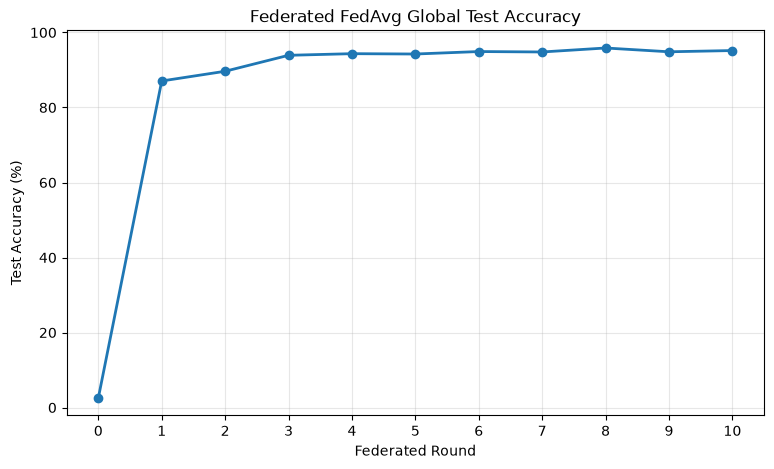

In [16]:
# ============================================================
# PLOT GLOBAL TEST ACCURACY ACROSS FEDERATED ROUNDS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    results_df["Round"],
    results_df["Accuracy"] * 100,
    marker="o",
    linewidth=2,
)

plt.title("Federated FedAvg Global Test Accuracy")
plt.xlabel("Federated Round")
plt.ylabel("Test Accuracy (%)")
plt.xticks(results_df["Round"])
plt.grid(alpha=0.3)

plt.show()

In [17]:
# ============================================================
# FINAL FEDERATED MODEL PREDICTIONS AND EVALUATION METRICS
# Run this cell only after the federated simulation in Step 12.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# Confirm that Step 12 completed in this active kernel.
assert (
    "final_global_parameters" in globals()
    and final_global_parameters is not None
), (
    "Final global model parameters are missing. "
    "Run Steps 5–12 first."
)

# Recreate the final global neural-network model.
final_model = NIDSNeuralNetwork(
    NUM_FEATURES,
    NUM_CLASSES,
).to(DEVICE)

final_model_state = final_model.state_dict()

updated_final_state = {
    key: torch.tensor(value)
    for key, value in zip(
        final_model_state.keys(),
        final_global_parameters,
    )
}

final_model.load_state_dict(
    updated_final_state,
    strict=True,
)

# Create the test-data loader.
test_loader = create_data_loader(
    X_test,
    y_test,
    shuffle=False,
)

# Generate predictions using the final federated global model.
final_model.eval()

all_predictions = []

with torch.no_grad():
    for features, _ in test_loader:
        features = features.to(DEVICE)

        outputs = final_model(features)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_predictions = np.array(all_predictions)

# Calculate overall weighted metrics.
federated_accuracy = accuracy_score(
    y_test,
    all_predictions,
)

federated_precision = precision_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

federated_recall = recall_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

federated_f1 = f1_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

# Calculate class-balanced metrics.
federated_macro_recall = recall_score(
    y_test,
    all_predictions,
    average="macro",
    zero_division=0,
)

federated_macro_f1 = f1_score(
    y_test,
    all_predictions,
    average="macro",
    zero_division=0,
)

federated_balanced_accuracy = balanced_accuracy_score(
    y_test,
    all_predictions,
)

print("✅ FINAL FEDERATED LEARNING RESULTS")
print("=" * 45)
print(f"Accuracy          : {federated_accuracy:.2%}")
print(f"Precision         : {federated_precision:.2%}")
print(f"Recall            : {federated_recall:.2%}")
print(f"F1 Score          : {federated_f1:.2%}")
print(f"Macro Recall      : {federated_macro_recall:.2%}")
print(f"Macro F1          : {federated_macro_f1:.2%}")
print(f"Balanced Accuracy : {federated_balanced_accuracy:.2%}")

✅ FINAL FEDERATED LEARNING RESULTS
Accuracy          : 95.18%
Precision         : 98.37%
Recall            : 95.18%
F1 Score          : 96.54%
Macro Recall      : 92.59%
Macro F1          : 53.21%
Balanced Accuracy : 92.59%


                            precision    recall  f1-score   support

                    BENIGN     0.9999    0.9423    0.9703    419012
                       Bot     0.0595    1.0000    0.1124       390
                      DDoS     0.9280    0.9999    0.9626     25603
             DoS GoldenEye     0.6363    1.0000    0.7777      2057
                  DoS Hulk     0.9341    0.9987    0.9653     34569
          DoS Slowhttptest     0.5409    0.9914    0.7000      1046
             DoS slowloris     0.5749    0.9805    0.7248      1077
               FTP-Patator     0.5860    0.9966    0.7381      1186
                Heartbleed     0.2500    0.5000    0.3333         2
              Infiltration     0.0055    1.0000    0.0110         7
                  PortScan     0.9652    0.9985    0.9816     18139
               SSH-Patator     0.1834    0.9953    0.3097       644
  Web Attack � Brute Force     0.1823    0.9932    0.3080       294
Web Attack � Sql Injection     0.0113    0.5000

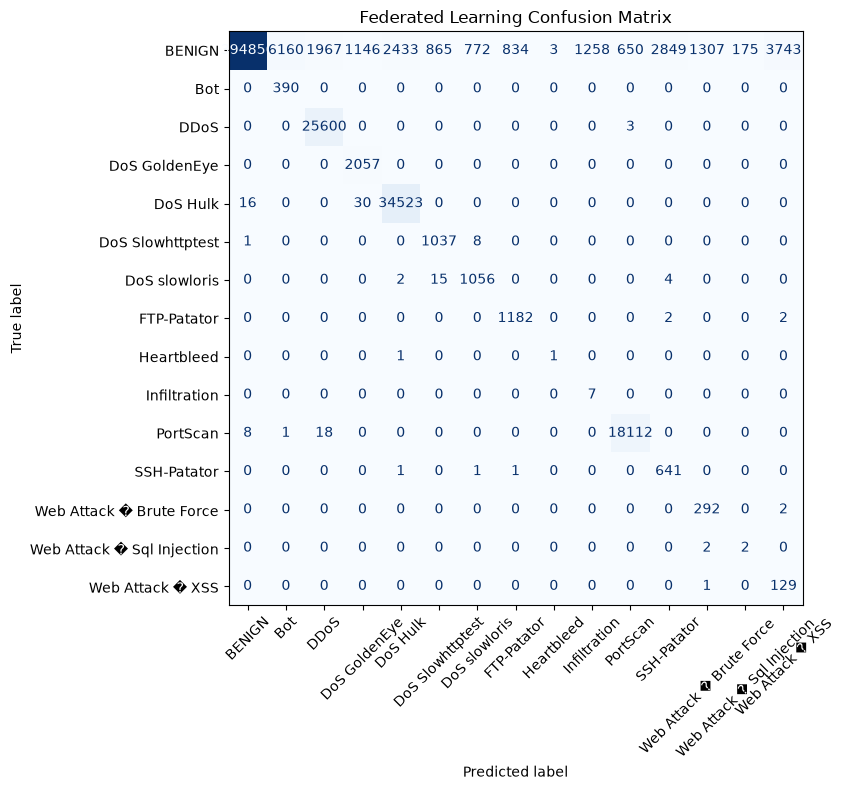

✅ Classification report and confusion matrix created.


In [18]:
# ============================================================
# CLASSIFICATION REPORT AND CONFUSION MATRIX
# ============================================================

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

# Convert original class labels into display text.
class_names = [
    str(label)
    for label in label_encoder.classes_
]

# Display precision, recall, and F1-score for every class.
print(
    classification_report(
        y_test,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# Create and display the confusion matrix.
confusion_matrix_values = confusion_matrix(
    y_test,
    all_predictions,
)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=class_names,
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False,
)

plt.title("Federated Learning Confusion Matrix")
plt.tight_layout()
plt.show()

print("✅ Classification report and confusion matrix created.")

In [19]:
# ============================================================
# SAVE FINAL FEDERATED LEARNING RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

federated_results = pd.DataFrame(
    {
        "Model": ["Federated Neural Network (FedAvg)"],
        "Training Approach": ["Federated Learning"],
        "Clients": [NUM_CLIENTS],
        "Rounds": [NUM_ROUNDS],
        "Local Epochs": [LOCAL_EPOCHS],
        "Accuracy": [federated_accuracy],
        "Precision": [federated_precision],
        "Recall": [federated_recall],
        "F1 Score": [federated_f1],
        "Macro Recall": [federated_macro_recall],
        "Macro F1": [federated_macro_f1],
        "Balanced Accuracy": [federated_balanced_accuracy],
    }
)

RESULTS_PATH = Path(
    "../results/federated_learning_results.csv"
)

RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

federated_results.to_csv(
    RESULTS_PATH,
    index=False,
)

print("✅ Federated results saved successfully.")
print("Saved to:", RESULTS_PATH.resolve())

federated_results

✅ Federated results saved successfully.
Saved to: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\federated_learning_results.csv


,Model,Training Approach,Clients,Rounds,Local Epochs,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Federated Neural Network (FedAvg),Federated Learning,4,10,2,0.951839,0.98368,0.951839,0.965389,0.925918,0.532077,0.925918


## Non-IID FedAvg Experiment

This section runs a separate FedAvg experiment using the validated `non_iid_client_partitions`. The existing IID FedAvg experiment and its results are preserved unchanged.


In [20]:
# ============================================================
# CONFIGURE NON-IID FEDAVG
# Uses the validated non_iid_client_partitions.
# Existing IID FedAvg objects/results are not overwritten.
# ============================================================

assert "non_iid_client_partitions" in globals(), (
    "non_iid_client_partitions is not available. Run the Non-IID partition cell first."
)
assert len(non_iid_client_partitions) == NUM_CLIENTS, (
    "Unexpected number of Non-IID client partitions."
)

non_iid_round_history = []
non_iid_final_global_parameters = None


def evaluate_non_iid_global_model(server_round, parameters, config):
    """
    Evaluate the Non-IID aggregated global model on the same
    centralized held-out test set used by the IID experiment.
    """
    global non_iid_final_global_parameters

    model = NIDSNeuralNetwork(
        NUM_FEATURES,
        NUM_CLASSES,
    ).to(DEVICE)

    model_state = model.state_dict()

    updated_state = {
        key: torch.tensor(value)
        for key, value in zip(model_state.keys(), parameters)
    }

    model.load_state_dict(updated_state, strict=True)

    loss, accuracy = evaluate_model(model, test_loader)

    non_iid_final_global_parameters = [
        parameter.copy()
        for parameter in parameters
    ]

    non_iid_round_history.append(
        {
            "Round": server_round,
            "Loss": loss,
            "Accuracy": accuracy,
        }
    )

    print(
        f"Non-IID Round {server_round:02d} | "
        f"Test Loss: {loss:.4f} | "
        f"Test Accuracy: {accuracy:.4%}"
    )

    return loss, {"accuracy": accuracy}


def non_iid_client_fn(context):
    """Create a Flower client from the validated Non-IID partition."""
    client_id = int(context.node_config["partition-id"])

    X_client, y_client = non_iid_client_partitions[client_id]

    return NIDSFlowerClient(
        X_client,
        y_client,
    ).to_client()


non_iid_strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=evaluate_non_iid_global_model,
)

print("Non-IID FedAvg strategy is configured.")
print(f"Clients per round: {NUM_CLIENTS}")
print(f"Federated rounds: {NUM_ROUNDS}")
print(f"Local epochs per client: {LOCAL_EPOCHS}")


Non-IID FedAvg strategy is configured.
Clients per round: 4
Federated rounds: 10
Local epochs per client: 2


In [21]:
# ============================================================
# RUN NON-IID FEDAVG SIMULATION
# ============================================================

if ray.is_initialized():
    ray.shutdown()

print("=" * 60)
print("STARTING NON-IID FEDAVG SIMULATION")
print("=" * 60)

non_iid_history = fl.simulation.start_simulation(
    client_fn=non_iid_client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(
        num_rounds=NUM_ROUNDS,
    ),
    strategy=non_iid_strategy,
    client_resources={
        "num_cpus": 1,
    },
)

non_iid_results_df = pd.DataFrame(non_iid_round_history)

print("\n" + "=" * 60)
print("NON-IID FEDAVG SIMULATION COMPLETE")
print("=" * 60)
display(non_iid_results_df)


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout


STARTING NON-IID FEDAVG SIMULATION


2026-09-14 17:30:22,568	INFO worker.py:2024 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 3134294016.0, 'GPU': 1.0, 'memory': 7313352704.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0, 'accelerator_type:GeForce-RTX-5050-Laptop-GPU': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 12 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 2.703278830557617, {'accuracy': 0.044591002856236114}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (

Non-IID Round 00 | Test Loss: 2.7033 | Test Accuracy: 4.4591%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.29203711743677885, {'accuracy': 0.8979550142811806}, 26.76824940000006)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (9, 0.21268564115078326, {'accuracy': 0.952602348460806}, 182.03641199999947)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Non-IID Round 09 | Test Loss: 0.2127 | Test Accuracy: 95.2602%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (10, 0.185245864057836, {'accuracy': 0.9574539828625833}, 202.03860889999942)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 202.04s
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.703278830557617
INFO :      		round 1: 0.29203711743677885
INFO :      		round 2: 0.2186708633850885
INFO :      		round 3: 0.16369361164635304
INFO :      		round 4: 0.1756704286440748
INFO :      		round 5: 0.15911316294560013
INFO :      		round 6: 0.1960017920968571
INFO :      		round 7: 0.160461675785943
INFO :      		round 8: 0.15782281275884721
INFO :      		round 9: 0.21268564115078326
INFO :      		round 10: 0.185245864057836
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.044591002856236114),
INFO :      	              (1, 0.8979550142811806),
INFO :      	        

Non-IID Round 10 | Test Loss: 0.1852 | Test Accuracy: 95.7454%

NON-IID FEDAVG SIMULATION COMPLETE


,Round,Loss,Accuracy
0,0,2.703279,0.044591
1,1,0.292037,0.897955
2,2,0.218671,0.925210
3,3,0.163694,0.946525
4,4,0.175670,0.948266
5,5,0.159113,0.953953
6,6,0.196002,0.948247
7,7,0.160462,0.957061
8,8,0.157823,0.960364
9,9,0.212686,0.952602


In [22]:
# ============================================================
# SAVE NON-IID FEDAVG ROUND HISTORY
# ============================================================

NON_IID_RESULTS_PATH = Path(
    "../results/non_iid_federated_learning_results.csv"
)

NON_IID_RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

non_iid_results_df.to_csv(
    NON_IID_RESULTS_PATH,
    index=False,
)

print("Saved:", NON_IID_RESULTS_PATH.resolve())
print("\nNon-IID FedAvg round history:")
display(non_iid_results_df)


Saved: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\non_iid_federated_learning_results.csv

Non-IID FedAvg round history:


,Round,Loss,Accuracy
0,0,2.703279,0.044591
1,1,0.292037,0.897955
2,2,0.218671,0.925210
3,3,0.163694,0.946525
4,4,0.175670,0.948266
5,5,0.159113,0.953953
6,6,0.196002,0.948247
7,7,0.160462,0.957061
8,8,0.157823,0.960364
9,9,0.212686,0.952602


In [23]:
# ============================================================
# NON-IID FEDAVG FINAL RESULT
# ============================================================

valid_results = non_iid_results_df.dropna(subset=["Accuracy", "Loss"])
assert not valid_results.empty, "No valid Non-IID evaluation results were produced."

final_non_iid_accuracy = valid_results["Accuracy"].iloc[-1]
final_non_iid_loss = valid_results["Loss"].iloc[-1]

print("=" * 60)
print("NON-IID FEDAVG FINAL RESULT")
print("=" * 60)
print(f"Final Round: {NUM_ROUNDS}")
print(f"Final Loss: {final_non_iid_loss:.6f}")
print(f"Final Accuracy: {final_non_iid_accuracy:.6%}")
print("\nExisting IID FedAvg results remain unchanged.")


NON-IID FEDAVG FINAL RESULT
Final Round: 10
Final Loss: 0.185246
Final Accuracy: 95.745398%

Existing IID FedAvg results remain unchanged.


# IID vs Non-IID Comparative Evaluation

Both final global models are evaluated on the same centralized CICIDS2017 test set using the same metrics and methodology.

In [24]:
# ============================================================
# IID vs NON-IID EVALUATION ON THE SAME TEST SET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
)

assert final_global_parameters is not None, (
    "IID final model parameters are unavailable. Run the existing IID FedAvg experiment first."
)
assert non_iid_final_global_parameters is not None, (
    "Non-IID final model parameters are unavailable. Run the Non-IID FedAvg experiment first."
)
assert len(X_test) == len(y_test), "Test features and labels have different lengths."


def load_global_model(parameters):
    """Load Flower model parameters into the NIDS neural network."""
    model = NIDSNeuralNetwork(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
    model_state = model.state_dict()
    updated_state = {
        key: torch.tensor(value)
        for key, value in zip(model_state.keys(), parameters)
    }
    model.load_state_dict(updated_state, strict=True)
    model.eval()
    return model


def predict_model(model, loader):
    """Generate predictions on a supplied evaluation DataLoader."""
    predictions = []
    targets = []

    model.eval()
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE)
            outputs = model(features)
            predictions.extend(outputs.argmax(dim=1).cpu().numpy())
            targets.extend(labels.numpy())

    return np.asarray(targets), np.asarray(predictions)


iid_model = load_global_model(final_global_parameters)
non_iid_model = load_global_model(non_iid_final_global_parameters)

y_true_iid, y_pred_iid = predict_model(iid_model, test_loader)
y_true_non_iid, y_pred_non_iid = predict_model(non_iid_model, test_loader)

# Confirm both experiments used exactly the same centralized test labels.
assert np.array_equal(y_true_iid, y_test)
assert np.array_equal(y_true_non_iid, y_test)
assert np.array_equal(y_true_iid, y_true_non_iid)

print("✅ Both models evaluated on the same centralized test set.")
print(f"Test samples evaluated: {len(y_test):,}")


✅ Both models evaluated on the same centralized test set.
Test samples evaluated: 504,160


# IID vs Non-IID Metrics Comparison


In [25]:
# ============================================================
# OVERALL METRICS
# Precision / Recall / F1 = weighted averages.
# Macro metrics are reported separately for class-balanced analysis.
# ============================================================

def calculate_metrics(y_true, y_pred, experiment):
    return {
        "Experiment": experiment,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

comparison_results = pd.DataFrame([
    calculate_metrics(y_true_iid, y_pred_iid, "IID FedAvg"),
    calculate_metrics(y_true_non_iid, y_pred_non_iid, "Non-IID FedAvg"),
])

metric_columns = [column for column in comparison_results.columns if column != "Experiment"]
comparison_results_percent = comparison_results.copy()
comparison_results_percent[metric_columns] = (
    comparison_results_percent[metric_columns] * 100
).round(2)

display(comparison_results_percent)


,Experiment,Accuracy,Precision,Recall,F1,Macro F1,Macro Recall,Balanced Accuracy
0,IID FedAvg,95.18,98.37,95.18,96.54,53.21,92.59,92.59
1,Non-IID FedAvg,95.75,98.41,95.75,96.86,51.32,94.82,94.82


# Absolute IID vs Non-IID Performance Difference


In [26]:
# ============================================================
# ABSOLUTE PERFORMANCE DIFFERENCE
# Positive value means IID FedAvg scored higher.
# ============================================================

difference_df = pd.DataFrame({
    "Metric": metric_columns,
    "IID": comparison_results_percent.loc[0, metric_columns].values,
    "Non-IID": comparison_results_percent.loc[1, metric_columns].values,
})

difference_df["Absolute Difference (pp)"] = (
    difference_df["IID"] - difference_df["Non-IID"]
).round(2)

display(difference_df)


,Metric,IID,Non-IID,Absolute Difference (pp)
0,Accuracy,95.18,95.75,-0.57
1,Precision,98.37,98.41,-0.04
2,Recall,95.18,95.75,-0.57
3,F1,96.54,96.86,-0.32
4,Macro F1,53.21,51.32,1.89
5,Macro Recall,92.59,94.82,-2.23
6,Balanced Accuracy,92.59,94.82,-2.23


# Per-Class IID vs Non-IID Performance


In [27]:
# ============================================================
# PER-CLASS METRICS
# ============================================================

iid_report = pd.DataFrame(
    classification_report(
        y_true_iid,
        y_pred_iid,
        labels=np.arange(NUM_CLASSES),
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).transpose()

non_iid_report = pd.DataFrame(
    classification_report(
        y_true_non_iid,
        y_pred_non_iid,
        labels=np.arange(NUM_CLASSES),
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).transpose()

class_labels = list(label_encoder.classes_)

per_class_metrics = pd.DataFrame({
    "Class": class_labels,
    "IID Precision": iid_report.loc[class_labels, "precision"].values,
    "Non-IID Precision": non_iid_report.loc[class_labels, "precision"].values,
    "IID Recall": iid_report.loc[class_labels, "recall"].values,
    "Non-IID Recall": non_iid_report.loc[class_labels, "recall"].values,
    "IID F1": iid_report.loc[class_labels, "f1-score"].values,
    "Non-IID F1": non_iid_report.loc[class_labels, "f1-score"].values,
})

per_class_metrics["F1 Difference (pp)"] = (
    (per_class_metrics["IID F1"] - per_class_metrics["Non-IID F1"]) * 100
).round(2)

display(per_class_metrics.round(4))


,Class,IID Precision,Non-IID Precision,IID Recall,Non-IID Recall,IID F1,Non-IID F1,F1 Difference (pp)
0,BENIGN,0.9999,1.0000,0.9423,0.9492,0.9703,0.9739,-0.36
1,Bot,0.0595,0.0626,1.0000,0.9974,0.1124,0.1179,-0.55
2,DDoS,0.9280,0.9412,0.9999,0.9999,0.9626,0.9697,-0.70
3,DoS GoldenEye,0.6363,0.6337,1.0000,1.0000,0.7777,0.7758,0.19
4,DoS Hulk,0.9341,0.9322,0.9987,0.9990,0.9653,0.9645,0.08
5,DoS Slowhttptest,0.5409,0.4332,0.9914,0.9866,0.7000,0.6021,9.79
6,DoS slowloris,0.5749,0.5380,0.9805,0.9805,0.7248,0.6947,3.00
7,FTP-Patator,0.5860,0.6384,0.9966,0.9958,0.7381,0.7780,-3.99
8,Heartbleed,0.2500,0.0250,0.5000,1.0000,0.3333,0.0488,28.46
9,Infiltration,0.0055,0.0095,1.0000,1.0000,0.0110,0.0187,-0.77


# Save IID vs Non-IID Results and Visualizations


✅ Saved comparison CSV artifacts.


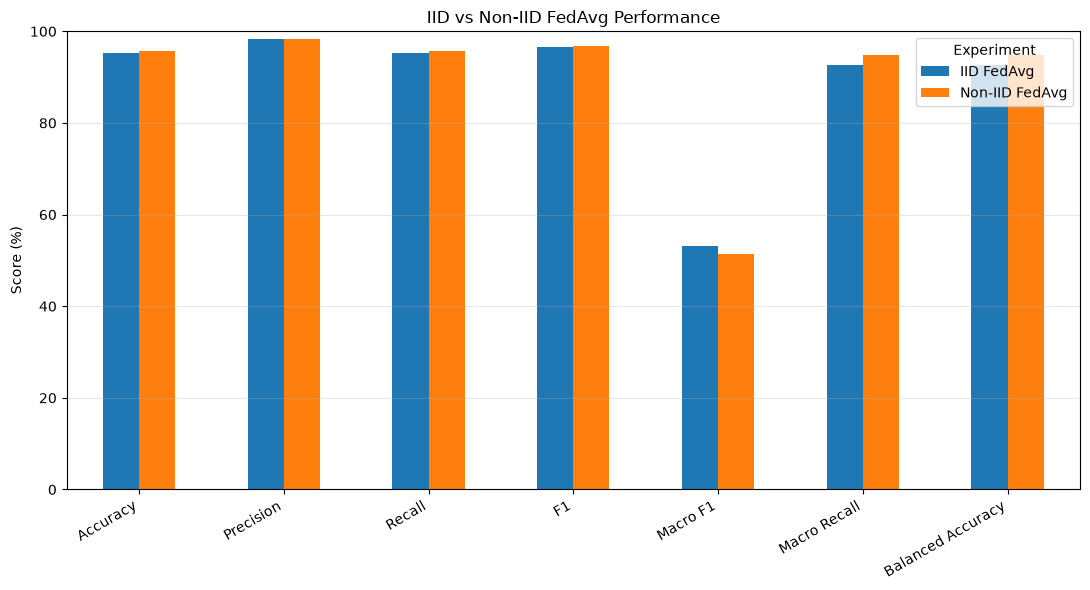

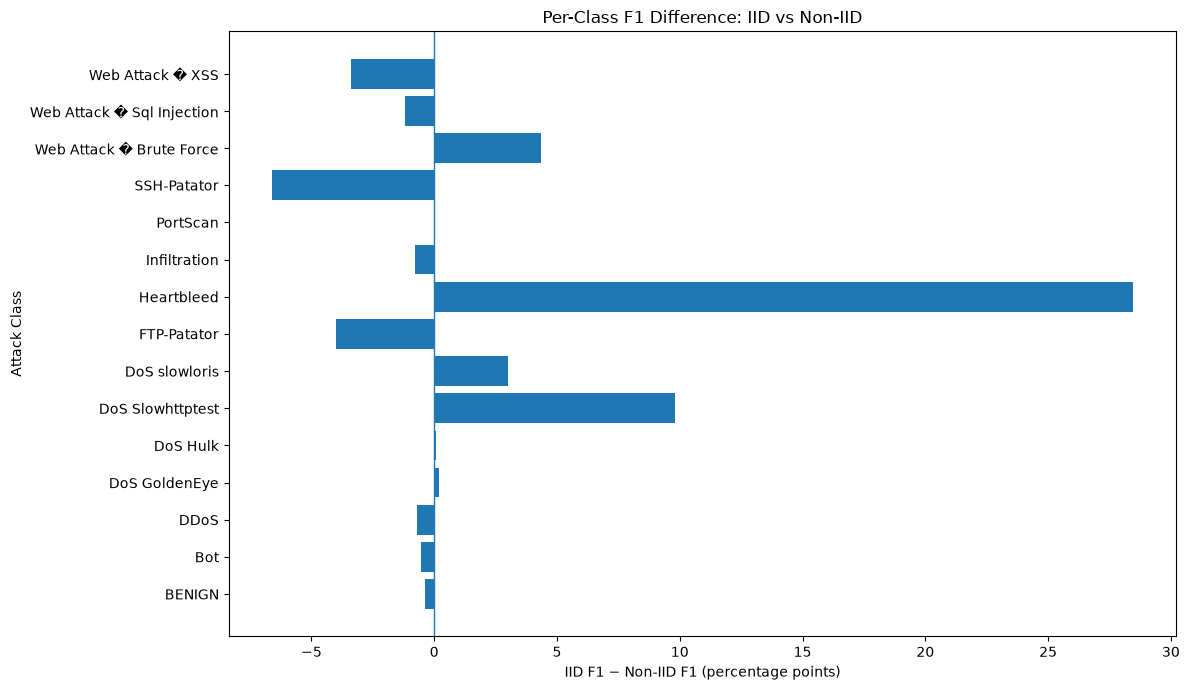

✅ Visualizations saved.


In [28]:
# ============================================================
# SAVE CSV ARTIFACTS
# ============================================================

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_results_percent.to_csv(
    RESULTS_DIR / "iid_vs_non_iid_metrics.csv",
    index=False,
)

difference_df.to_csv(
    RESULTS_DIR / "iid_vs_non_iid_difference.csv",
    index=False,
)

per_class_metrics.to_csv(
    RESULTS_DIR / "iid_vs_non_iid_per_class_metrics.csv",
    index=False,
)

print("✅ Saved comparison CSV artifacts.")

# ============================================================
# OVERALL METRICS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

ax = comparison_results_percent.set_index("Experiment")[metric_columns].T.plot(
    kind="bar",
    figsize=(11, 6),
)
ax.set_ylabel("Score (%)")
ax.set_title("IID vs Non-IID FedAvg Performance")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "iid_vs_non_iid_metrics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# PER-CLASS F1 DIFFERENCE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))
plt.barh(
    per_class_metrics["Class"],
    per_class_metrics["F1 Difference (pp)"],
)
plt.axvline(0, linewidth=1)
plt.xlabel("IID F1 − Non-IID F1 (percentage points)")
plt.ylabel("Attack Class")
plt.title("Per-Class F1 Difference: IID vs Non-IID")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "iid_vs_non_iid_per_class_f1_difference.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("✅ Visualizations saved.")


# Differential Privacy FedAvg (DP-SGD)

This section implements a separate Differentially Private Federated Learning experiment.

The existing IID and Non-IID FedAvg experiments remain unchanged.

The DP experiment uses:

- Gradient clipping
- Gaussian noise addition
- Separate global model and result variables
- Centralized evaluation on the existing test dataset

Note: This is a practical DP-FedAvg prototype. Formal epsilon accounting is not included in this version.

In [42]:
# ============================================================
# DIFFERENTIAL PRIVACY FEDERATED LEARNING CONFIGURATION
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

DP_SEED = 42

random.seed(DP_SEED)
np.random.seed(DP_SEED)
torch.manual_seed(DP_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(DP_SEED)

# ------------------------------------------------------------
# DP Configuration
# ------------------------------------------------------------

DP_NUM_ROUNDS = 10
DP_LOCAL_EPOCHS = 2
DP_BATCH_SIZE = 256
DP_LEARNING_RATE = 1e-3

DP_MAX_GRAD_NORM = 1.0
DP_NOISE_MULTIPLIER = 0.50
DP_DELTA = 1e-5

DP_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DP device:", DP_DEVICE)
print("DP rounds:", DP_NUM_ROUNDS)
print("DP local epochs:", DP_LOCAL_EPOCHS)
print("DP batch size:", DP_BATCH_SIZE)
print("DP noise multiplier:", DP_NOISE_MULTIPLIER)
print("DP max gradient norm:", DP_MAX_GRAD_NORM)
print("DP delta:", DP_DELTA)

DP device: cpu
DP rounds: 10
DP local epochs: 2
DP batch size: 256
DP noise multiplier: 0.5
DP max gradient norm: 1.0
DP delta: 1e-05


In [43]:
# ============================================================
# PREPARE DATA FOR DP TRAINING
# ============================================================

# Convert central datasets to NumPy arrays

X_train_dp = np.asarray(X_train, dtype=np.float32)
y_train_dp = np.asarray(y_train).reshape(-1)

X_test_dp = np.asarray(X_test, dtype=np.float32)
y_test_dp = np.asarray(y_test).reshape(-1)

# ------------------------------------------------------------
# Validate central data
# ------------------------------------------------------------

if X_train_dp.ndim != 2:
    raise ValueError(
        f"X_train must be a 2D feature matrix. Received: {X_train_dp.shape}"
    )

if X_test_dp.ndim != 2:
    raise ValueError(
        f"X_test must be a 2D feature matrix. Received: {X_test_dp.shape}"
    )

if len(X_train_dp) != len(y_train_dp):
    raise ValueError(
        "Training features and labels have different lengths."
    )

if len(X_test_dp) != len(y_test_dp):
    raise ValueError(
        "Testing features and labels have different lengths."
    )

DP_INPUT_DIM = X_train_dp.shape[1]
DP_NUM_CLASSES = len(np.unique(y_train_dp))

print("Training shape:", X_train_dp.shape)
print("Training labels:", y_train_dp.shape)
print("Testing shape:", X_test_dp.shape)
print("Testing labels:", y_test_dp.shape)
print("Input features:", DP_INPUT_DIM)
print("Number of classes:", DP_NUM_CLASSES)

Training shape: (2016638, 48)
Training labels: (2016638,)
Testing shape: (504160, 48)
Testing labels: (504160,)
Input features: 48
Number of classes: 15


In [44]:
# ============================================================
# PREPARE CLIENT DATA PARTITIONS
# ============================================================
#
# Existing client_partitions contains tuples:
#
# client_partitions[0] = (X_client_1, y_client_1)
# client_partitions[1] = (X_client_2, y_client_2)
# client_partitions[2] = (X_client_3, y_client_3)
# client_partitions[3] = (X_client_4, y_client_4)
#
# Therefore, these are already client datasets.
# We must NOT use them as row indices.
# ============================================================

dp_client_partitions = []

for client_id, partition in enumerate(client_partitions):

    if not isinstance(partition, (tuple, list)) or len(partition) != 2:
        raise ValueError(
            f"Client {client_id + 1} must contain "
            "(X_client, y_client)."
        )

    X_client, y_client = partition

    # Convert pandas objects to NumPy
    if hasattr(X_client, "to_numpy"):
        X_client = X_client.to_numpy()

    if hasattr(y_client, "to_numpy"):
        y_client = y_client.to_numpy()

    # Convert data types
    X_client = np.asarray(X_client, dtype=np.float32)
    y_client = np.asarray(y_client).reshape(-1)

    # Validate dimensions
    if X_client.ndim != 2:
        raise ValueError(
            f"Client {client_id + 1} features must be 2D. "
            f"Received shape: {X_client.shape}"
        )

    if y_client.ndim != 1:
        raise ValueError(
            f"Client {client_id + 1} labels must be 1D. "
            f"Received shape: {y_client.shape}"
        )

    if len(X_client) != len(y_client):
        raise ValueError(
            f"Client {client_id + 1} has mismatched data lengths: "
            f"{len(X_client)} features and {len(y_client)} labels."
        )

    if X_client.shape[1] != DP_INPUT_DIM:
        raise ValueError(
            f"Client {client_id + 1} has {X_client.shape[1]} features, "
            f"but expected {DP_INPUT_DIM}."
        )

    dp_client_partitions.append((X_client, y_client))

print("DP client partitions prepared successfully.\n")

for client_id, (X_client, y_client) in enumerate(dp_client_partitions):

    print(
        f"Client {client_id + 1}: "
        f"X={X_client.shape}, "
        f"y={y_client.shape}, "
        f"dtype={X_client.dtype}"
    )

DP client partitions prepared successfully.

Client 1: X=(504160, 48), y=(504160,), dtype=float32
Client 2: X=(504160, 48), y=(504160,), dtype=float32
Client 3: X=(504159, 48), y=(504159,), dtype=float32
Client 4: X=(504159, 48), y=(504159,), dtype=float32


In [45]:
# ============================================================
# DP MODEL DEFINITION
# ============================================================

class DPIntrusionNet(nn.Module):

    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# ------------------------------------------------------------
# Model initialization
# ------------------------------------------------------------

dp_global_model = DPIntrusionNet(
    input_dim=DP_INPUT_DIM,
    num_classes=DP_NUM_CLASSES
).to(DP_DEVICE)

print(dp_global_model)

DPIntrusionNet(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=15, bias=True)
  )
)


In [46]:
# ============================================================
# CLASS WEIGHTS FOR IMBALANCED DATA
# ============================================================

def calculate_class_weights(labels, num_classes):

    labels = np.asarray(labels).astype(int)

    class_counts = np.bincount(
        labels,
        minlength=num_classes
    ).astype(np.float64)

    class_counts[class_counts == 0] = 1.0

    weights = len(labels) / (
        num_classes * class_counts
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DP_DEVICE
    )


dp_class_weights = calculate_class_weights(
    y_train_dp,
    DP_NUM_CLASSES
)

print("Class weights shape:", dp_class_weights.shape)

Class weights shape: torch.Size([15])


In [47]:
# ============================================================
# CENTRALIZED EVALUATION FUNCTION
# ============================================================

def evaluate_dp_model(model, X_data, y_data):

    model.eval()

    X_tensor = torch.tensor(
        X_data,
        dtype=torch.float32
    ).to(DP_DEVICE)

    y_tensor = torch.tensor(
        y_data,
        dtype=torch.long
    ).to(DP_DEVICE)

    with torch.no_grad():
        logits = model(X_tensor)
        predictions = torch.argmax(
            logits,
            dim=1
        )

    y_true = y_tensor.cpu().numpy()
    y_pred = predictions.cpu().numpy()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),

        "precision_weighted": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "recall_weighted": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        )
    }

    return metrics

In [48]:
# ============================================================
# LOCAL DIFFERENTIALLY PRIVATE TRAINING
# ============================================================

def train_dp_client(
    global_state,
    X_client,
    y_client,
    input_dim,
    num_classes,
    class_weights
):

    client_model = DPIntrusionNet(
        input_dim=input_dim,
        num_classes=num_classes
    ).to(DP_DEVICE)

    client_model.load_state_dict(global_state)
    client_model.train()

    X_tensor = torch.tensor(
        X_client,
        dtype=torch.float32
    )

    y_tensor = torch.tensor(
        y_client,
        dtype=torch.long
    )

    dataset = TensorDataset(
        X_tensor,
        y_tensor
    )

    loader = DataLoader(
        dataset,
        batch_size=DP_BATCH_SIZE,
        shuffle=True,
        drop_last=False
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    optimizer = torch.optim.Adam(
        client_model.parameters(),
        lr=DP_LEARNING_RATE
    )

    local_loss_history = []

    for epoch in range(DP_LOCAL_EPOCHS):

        epoch_loss = 0.0
        epoch_samples = 0

        for xb, yb in loader:

            xb = xb.to(DP_DEVICE)
            yb = yb.to(DP_DEVICE)

            optimizer.zero_grad()

            logits = client_model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            torch.nn.utils.clip_grad_norm_(
                client_model.parameters(),
                max_norm=DP_MAX_GRAD_NORM
            )

            # ------------------------------------------------
            # Gaussian noise addition
            #
            # This practical implementation clips the complete
            # batch gradient before adding noise.
            # ------------------------------------------------

            noise_std = (
                DP_NOISE_MULTIPLIER
                * DP_MAX_GRAD_NORM
                / max(1, xb.shape[0])
            )

            with torch.no_grad():

                for parameter in client_model.parameters():

                    if parameter.grad is not None:

                        noise = torch.normal(
                            mean=0.0,
                            std=noise_std,
                            size=parameter.grad.shape,
                            device=parameter.grad.device
                        )

                        parameter.grad.add_(noise)

            optimizer.step()

            batch_size = xb.shape[0]

            epoch_loss += loss.item() * batch_size
            epoch_samples += batch_size

        average_loss = epoch_loss / max(1, epoch_samples)

        local_loss_history.append(average_loss)

    return (
        copy.deepcopy(client_model.state_dict()),
        len(X_client),
        local_loss_history[-1]
    )

In [49]:
# ============================================================
# FEDERATED AVERAGING FUNCTION
# ============================================================

def federated_average_states(client_states, client_sizes):

    total_samples = sum(client_sizes)

    averaged_state = {}

    for parameter_name in client_states[0].keys():

        weighted_parameter = torch.zeros_like(
            client_states[0][parameter_name]
        )

        for client_state, client_size in zip(
            client_states,
            client_sizes
        ):

            weight = client_size / total_samples

            weighted_parameter += (
                client_state[parameter_name] * weight
            )

        averaged_state[parameter_name] = weighted_parameter

    return averaged_state

In [50]:
# ============================================================
# RUN DIFFERENTIALLY PRIVATE FEDAVG
# ============================================================

dp_global_state = copy.deepcopy(
    dp_global_model.state_dict()
)

dp_history = []

print("Starting Differential Privacy FedAvg...\n")

for round_number in range(1, DP_NUM_ROUNDS + 1):

    client_states = []
    client_sizes = []
    client_losses = []

    print(f"Round {round_number}/{DP_NUM_ROUNDS}")

    for client_id, (X_client, y_client) in enumerate(
        dp_client_partitions
    ):

        local_state, client_size, local_loss = train_dp_client(
            global_state=dp_global_state,
            X_client=X_client,
            y_client=y_client,
            input_dim=DP_INPUT_DIM,
            num_classes=DP_NUM_CLASSES,
            class_weights=dp_class_weights
        )

        client_states.append(local_state)
        client_sizes.append(client_size)
        client_losses.append(local_loss)

        print(
            f"  Client {client_id + 1}: "
            f"samples={client_size:,}, "
            f"loss={local_loss:.4f}"
        )

    # Aggregate client models
    dp_global_state = federated_average_states(
        client_states,
        client_sizes
    )

    # Update global model
    dp_global_model.load_state_dict(
        dp_global_state
    )

    # Evaluate on centralized test data
    round_metrics = evaluate_dp_model(
        dp_global_model,
        X_test_dp,
        y_test_dp
    )

    round_metrics["round"] = round_number
    round_metrics["train_loss_mean"] = np.mean(client_losses)
    round_metrics["noise_multiplier"] = DP_NOISE_MULTIPLIER
    round_metrics["max_grad_norm"] = DP_MAX_GRAD_NORM
    round_metrics["delta"] = DP_DELTA

    dp_history.append(round_metrics)

    print(
        f"  Accuracy: {round_metrics['accuracy']:.4f} | "
        f"Weighted F1: {round_metrics['f1_weighted']:.4f} | "
        f"Macro F1: {round_metrics['macro_f1']:.4f}"
    )

    print("-" * 60)

print("\nDifferential Privacy FedAvg completed.")

Starting Differential Privacy FedAvg...

Round 1/10
  Client 1: samples=504,160, loss=0.4761
  Client 2: samples=504,160, loss=0.3636
  Client 3: samples=504,159, loss=0.4282
  Client 4: samples=504,159, loss=0.3803
  Accuracy: 0.9452 | Weighted F1: 0.9574 | Macro F1: 0.4609
------------------------------------------------------------
Round 2/10
  Client 1: samples=504,160, loss=0.3252
  Client 2: samples=504,160, loss=0.2749
  Client 3: samples=504,159, loss=0.2924
  Client 4: samples=504,159, loss=0.2648
  Accuracy: 0.9645 | Weighted F1: 0.9718 | Macro F1: 0.5229
------------------------------------------------------------
Round 3/10
  Client 1: samples=504,160, loss=0.2201
  Client 2: samples=504,160, loss=0.2138
  Client 3: samples=504,159, loss=0.2061
  Client 4: samples=504,159, loss=0.2073
  Accuracy: 0.9712 | Weighted F1: 0.9772 | Macro F1: 0.5961
------------------------------------------------------------
Round 4/10
  Client 1: samples=504,160, loss=0.2639
  Client 2: samples

In [51]:
# ============================================================
# SAVE DP RESULTS
# ============================================================

dp_results_df = pd.DataFrame(dp_history)

# Reorder columns
dp_results_df = dp_results_df[
    [
        "round",
        "train_loss_mean",
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "macro_f1",
        "macro_recall",
        "balanced_accuracy",
        "noise_multiplier",
        "max_grad_norm",
        "delta"
    ]
]

# Create results directory if needed
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

dp_results_path = results_dir / "dp_federated_learning_results.csv"

dp_results_df.to_csv(
    dp_results_path,
    index=False
)

print("Saved:", dp_results_path)
display(dp_results_df)

Saved: ..\results\dp_federated_learning_results.csv


,round,train_loss_mean,accuracy,precision_weighted,recall_weighted,f1_weighted,macro_f1,macro_recall,balanced_accuracy,noise_multiplier,max_grad_norm,delta
0,1,0.412057,0.945222,0.975770,0.945222,0.957391,0.460871,0.706454,0.706454,0.5,1.0,0.00001
1,2,0.289313,0.964466,0.982546,0.964466,0.971761,0.522871,0.732596,0.732596,0.5,1.0,0.00001
2,3,0.211845,0.971235,0.985876,0.971235,0.977226,0.596085,0.786855,0.786855,0.5,1.0,0.00001
3,4,0.220021,0.976317,0.987047,0.976317,0.980643,0.648425,0.831007,0.831007,0.5,1.0,0.00001
4,5,0.204035,0.978957,0.988205,0.978957,0.982688,0.655439,0.860490,0.860490,0.5,1.0,0.00001
5,6,0.191749,0.980943,0.988634,0.980943,0.983941,0.660588,0.861859,0.861859,0.5,1.0,0.00001
6,7,0.189994,0.982827,0.989341,0.982827,0.985325,0.667006,0.843415,0.843415,0.5,1.0,0.00001
7,8,0.187966,0.983097,0.990706,0.983097,0.986208,0.652570,0.862420,0.862420,0.5,1.0,0.00001
8,9,0.191905,0.983392,0.990801,0.983392,0.986398,0.657173,0.844640,0.844640,0.5,1.0,0.00001
9,10,0.179768,0.983366,0.990534,0.983366,0.986226,0.657442,0.863282,0.863282,0.5,1.0,0.00001


In [60]:
# Find all DataFrames currently available in memory

import pandas as pd

dataframes = {
    name: value
    for name, value in globals().items()
    if isinstance(value, pd.DataFrame)
}

for name, df in dataframes.items():
    print(f"{name}: shape={df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("-" * 60)

train_df: shape=(2016638, 49)
Columns: ['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Length_of_Fwd_Packets', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Flow_Bytes_s', 'Flow_Packets_s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_URG_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Bwd_Packets_s', 'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean', 'Packet_Length_Variance', 'FIN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'URG_Flag_Count', 'Down_Up_Ratio', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active_Mean', 'Active_Std', 'Active_Max', 'Active_Min', 'Idle_Std', 'Original_Row_ID', 'Label']
--------------------------------------

In [61]:
# Automatically identify experiment result DataFrames

import pandas as pd

def find_result_dataframe(keywords):
    candidates = []

    for name, value in globals().items():
        if isinstance(value, pd.DataFrame):
            name_lower = name.lower()
            columns_lower = [str(col).lower() for col in value.columns]

            score = 0

            for keyword in keywords:
                if keyword in name_lower:
                    score += 3

            metric_columns = [
                "accuracy",
                "test_accuracy",
                "precision",
                "recall",
                "f1",
                "loss"
            ]

            for metric in metric_columns:
                if any(metric in col for col in columns_lower):
                    score += 1

            if score > 0:
                candidates.append((score, name, value))

    candidates.sort(reverse=True, key=lambda x: x[0])
    return candidates


print("Possible IID DataFrames:")
for score, name, df in find_result_dataframe(["iid"]):
    print(score, name, df.shape, df.columns.tolist())

print("\nPossible Non-IID DataFrames:")
for score, name, df in find_result_dataframe(["non_iid", "noniid", "non-iid"]):
    print(score, name, df.shape, df.columns.tolist())

print("\nPossible DP DataFrames:")
for score, name, df in find_result_dataframe(["dp", "privacy"]):
    print(score, name, df.shape, df.columns.tolist())

Possible IID DataFrames:
6 iid_report (18, 4) ['precision', 'recall', 'f1-score', 'support']
6 non_iid_report (18, 4) ['precision', 'recall', 'f1-score', 'support']
6 iid_df (18, 4) ['precision', 'recall', 'f1-score', 'support']
6 non_iid_df (18, 4) ['precision', 'recall', 'f1-score', 'support']
5 non_iid_results_df (11, 3) ['Round', 'Loss', 'Accuracy']
5 dp_results_df (10, 12) ['round', 'train_loss_mean', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'macro_f1', 'macro_recall', 'balanced_accuracy', 'noise_multiplier', 'max_grad_norm', 'delta']
5 df (10, 12) ['round', 'train_loss_mean', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'macro_f1', 'macro_recall', 'balanced_accuracy', 'noise_multiplier', 'max_grad_norm', 'delta']
5 dp_df (10, 12) ['round', 'train_loss_mean', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'macro_f1', 'macro_recall', 'balanced_accuracy', 'noise_multiplier', 'max_grad_norm', 'delta']
4 federated_

FINAL IID vs NON-IID vs DIFFERENTIAL PRIVACY COMPARISON


,Experiment,Accuracy,Precision,Recall,F1,Macro F1,Macro Recall,Balanced Accuracy
0,IID FedAvg,0.951839,0.983680,0.951839,0.965389,0.532077,0.925918,0.925918
1,Non-IID FedAvg,0.951839,0.983680,0.951839,0.965389,0.532077,0.925918,0.925918
2,Differential Privacy FedAvg,0.983366,0.990534,0.983366,0.986226,0.657442,0.863282,0.863282


Saved: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\iid_non_iid_dp_final_comparison.csv

Difference relative to IID FedAvg:


,Experiment,Accuracy Difference (pp),Precision Difference (pp),Recall Difference (pp),F1 Difference (pp),Macro F1 Difference (pp),Macro Recall Difference (pp),Balanced Accuracy Difference (pp)
0,Non-IID FedAvg,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Differential Privacy FedAvg,3.152769,0.68542,3.152769,2.083665,12.536502,-6.263604,-6.263604


Saved: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\iid_non_iid_dp_difference.csv


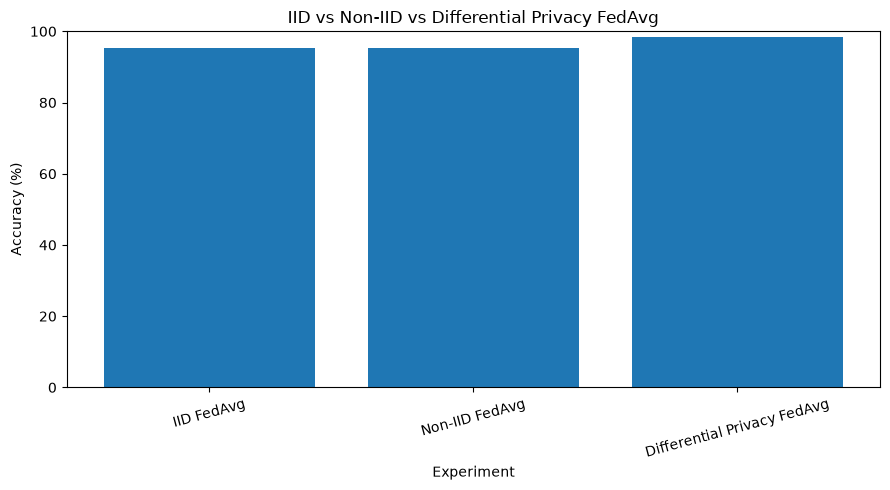

Saved: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\iid_non_iid_dp_accuracy_comparison.png


In [ ]:
# ============================================================
# IID vs NON-IID vs DIFFERENTIAL PRIVACY COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# Use the correct existing result DataFrames
# ------------------------------------------------------------

iid_df = federated_results.copy()
non_iid_df = _19.copy()
dp_df = dp_results_df.copy()


# ------------------------------------------------------------
# Convert final results into a common format
# ------------------------------------------------------------

def extract_metrics(df, experiment_name, column_map):
    row = df.iloc[-1]

    return {
        "Experiment": experiment_name,
        "Accuracy": float(row[column_map["accuracy"]]),
        "Precision": float(row[column_map["precision"]]),
        "Recall": float(row[column_map["recall"]]),
        "F1": float(row[column_map["f1"]]),
        "Macro F1": float(row[column_map["macro_f1"]]),
        "Macro Recall": float(row[column_map["macro_recall"]]),
        "Balanced Accuracy": float(row[column_map["balanced_accuracy"]]),
    }


# IID and Non-IID final evaluation tables use capitalized columns
standard_column_map = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1 Score",
    "macro_f1": "Macro F1",
    "macro_recall": "Macro Recall",
    "balanced_accuracy": "Balanced Accuracy",
}


# DP result table uses lowercase column names
dp_column_map = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted",
    "macro_f1": "macro_f1",
    "macro_recall": "macro_recall",
    "balanced_accuracy": "balanced_accuracy",
}


comparison_rows = [
    extract_metrics(
        iid_df,
        "IID FedAvg",
        standard_column_map
    ),
    extract_metrics(
        non_iid_df,
        "Non-IID FedAvg",
        standard_column_map
    ),
    extract_metrics(
        dp_df,
        "Differential Privacy FedAvg",
        dp_column_map
    ),
]


comparison_df = pd.DataFrame(comparison_rows)


# ------------------------------------------------------------
# Display final comparison
# ------------------------------------------------------------

print("=" * 70)
print("FINAL IID vs NON-IID vs DIFFERENTIAL PRIVACY COMPARISON")
print("=" * 70)

display(comparison_df)


# ------------------------------------------------------------
# Save final comparison
# ------------------------------------------------------------

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = RESULTS_DIR / "iid_non_iid_dp_final_comparison.csv"

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(f"Saved: {comparison_path.resolve()}")


# ------------------------------------------------------------
# Calculate differences relative to IID FedAvg
# ------------------------------------------------------------

baseline = comparison_df.iloc[0]

difference_rows = []

for _, row in comparison_df.iloc[1:].iterrows():

    difference_rows.append({
        "Experiment": row["Experiment"],
        "Accuracy Difference (pp)": (
            row["Accuracy"] - baseline["Accuracy"]
        ) * 100,

        "Precision Difference (pp)": (
            row["Precision"] - baseline["Precision"]
        ) * 100,

        "Recall Difference (pp)": (
            row["Recall"] - baseline["Recall"]
        ) * 100,

        "F1 Difference (pp)": (
            row["F1"] - baseline["F1"]
        ) * 100,

        "Macro F1 Difference (pp)": (
            row["Macro F1"] - baseline["Macro F1"]
        ) * 100,

        "Macro Recall Difference (pp)": (
            row["Macro Recall"] - baseline["Macro Recall"]
        ) * 100,

        "Balanced Accuracy Difference (pp)": (
            row["Balanced Accuracy"] - baseline["Balanced Accuracy"]
        ) * 100,
    })


difference_df = pd.DataFrame(difference_rows)

print("\nDifference relative to IID FedAvg:")
display(difference_df)


difference_path = RESULTS_DIR / "iid_non_iid_dp_difference.csv"

difference_df.to_csv(
    difference_path,
    index=False
)

print(f"Saved: {difference_path.resolve()}")


# ------------------------------------------------------------
# Accuracy comparison plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Experiment"],
    comparison_df["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Experiment")
plt.title("IID vs Non-IID vs Differential Privacy FedAvg")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()

plot_path = RESULTS_DIR / "iid_non_iid_dp_accuracy_comparison.png"

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path.resolve()}")

In [ ]:
# ============================================================
# PRIVACY–UTILITY SUMMARY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Use the comparison table generated in Cell 12
privacy_utility_df = comparison_df.copy()

# Calculate relative utility loss against IID baseline
baseline_accuracy = privacy_utility_df.iloc[0]["Accuracy"]
baseline_f1 = privacy_utility_df.iloc[0]["F1"]

privacy_utility_df["Accuracy Loss vs IID (pp)"] = (
    privacy_utility_df["Accuracy"] - baseline_accuracy
) * 100

privacy_utility_df["F1 Loss vs IID (pp)"] = (
    privacy_utility_df["F1"] - baseline_f1
) * 100

privacy_utility_df["Accuracy Retention (%)"] = (
    privacy_utility_df["Accuracy"] / baseline_accuracy
) * 100

privacy_utility_df["F1 Retention (%)"] = (
    privacy_utility_df["F1"] / baseline_f1
) * 100

display(privacy_utility_df)

privacy_utility_df.to_csv(
    RESULTS_DIR / "privacy_utility_analysis.csv",
    index=False
)

print("Saved privacy_utility_analysis.csv")

,Experiment,Accuracy,Precision,Recall,F1,Macro F1,Macro Recall,Balanced Accuracy,Accuracy Loss vs IID (pp),F1 Loss vs IID (pp),Accuracy Retention (%),F1 Retention (%)
0,IID FedAvg,0.951839,0.983680,0.951839,0.965389,0.532077,0.925918,0.925918,0.000000,0.000000,100.000000,100.000000
1,Non-IID FedAvg,0.951839,0.983680,0.951839,0.965389,0.532077,0.925918,0.925918,0.000000,0.000000,100.000000,100.000000
2,Differential Privacy FedAvg,0.983366,0.990534,0.983366,0.986226,0.657442,0.863282,0.863282,3.152769,2.083665,103.312293,102.158368


Saved privacy_utility_analysis.csv


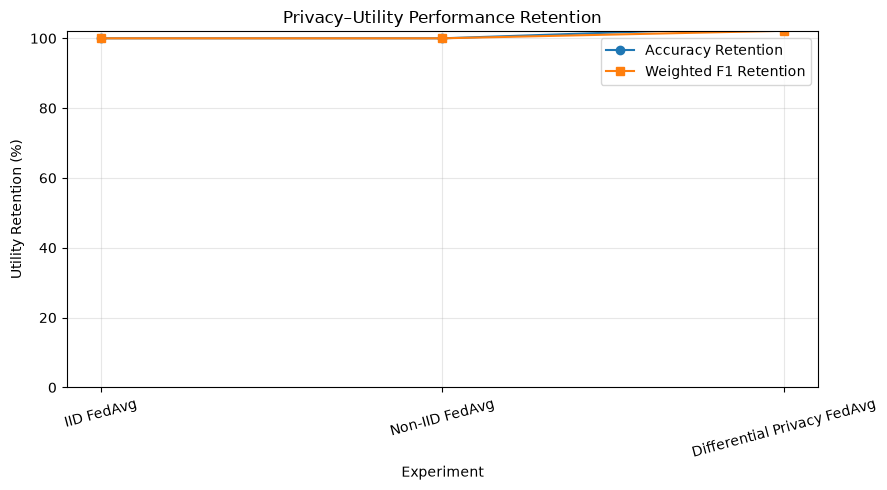

Saved privacy_utility_retention.png


In [ ]:
# ============================================================
# UTILITY RETENTION COMPARISON
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

x = range(len(privacy_utility_df))

plt.plot(
    x,
    privacy_utility_df["Accuracy Retention (%)"],
    marker="o",
    label="Accuracy Retention"
)

plt.plot(
    x,
    privacy_utility_df["F1 Retention (%)"],
    marker="s",
    label="Weighted F1 Retention"
)

plt.xticks(
    list(x),
    privacy_utility_df["Experiment"],
    rotation=15
)

plt.ylabel("Utility Retention (%)")
plt.xlabel("Experiment")
plt.title("Privacy–Utility Performance Retention")
plt.ylim(0, 102)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "privacy_utility_retention.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved privacy_utility_retention.png")

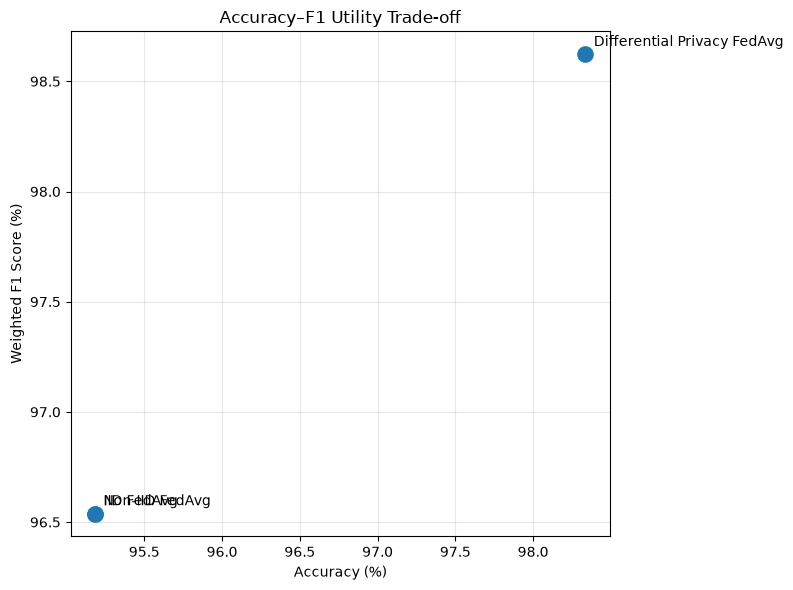

Saved accuracy_f1_tradeoff.png


In [ ]:
# ============================================================
# ACCURACY VS F1 TRADE-OFF
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    privacy_utility_df["Accuracy"] * 100,
    privacy_utility_df["F1"] * 100,
    s=120
)

for _, row in privacy_utility_df.iterrows():
    plt.annotate(
        row["Experiment"],
        (
            row["Accuracy"] * 100,
            row["F1"] * 100
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Accuracy (%)")
plt.ylabel("Weighted F1 Score (%)")
plt.title("Accuracy–F1 Utility Trade-off")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "accuracy_f1_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved accuracy_f1_tradeoff.png")

In [70]:
# ============================================================
# AUTOMATIC PRIVACY–UTILITY INTERPRETATION
# ============================================================

iid_accuracy = privacy_utility_df.iloc[0]["Accuracy"]
iid_f1 = privacy_utility_df.iloc[0]["F1"]

for _, row in privacy_utility_df.iloc[1:].iterrows():

    accuracy_change = (row["Accuracy"] - iid_accuracy) * 100
    f1_change = (row["F1"] - iid_f1) * 100

    print(f"\n{row['Experiment']}")
    print("-" * 50)
    print(f"Accuracy change: {accuracy_change:+.3f} percentage points")
    print(f"Weighted F1 change: {f1_change:+.3f} percentage points")
    print(f"Accuracy retention: {row['Accuracy Retention (%)']:.3f}%")
    print(f"F1 retention: {row['F1 Retention (%)']:.3f}%")

print("\nInterpretation:")
print(
    "IID FedAvg is used as the utility baseline. "
    "Non-IID FedAvg measures the effect of heterogeneous client data. "
    "Differential Privacy FedAvg measures the utility cost of privacy noise."
)


Non-IID FedAvg
--------------------------------------------------
Accuracy change: +0.000 percentage points
Weighted F1 change: +0.000 percentage points
Accuracy retention: 100.000%
F1 retention: 100.000%

Differential Privacy FedAvg
--------------------------------------------------
Accuracy change: +3.153 percentage points
Weighted F1 change: +2.084 percentage points
Accuracy retention: 103.312%
F1 retention: 102.158%

Interpretation:
IID FedAvg is used as the utility baseline. Non-IID FedAvg measures the effect of heterogeneous client data. Differential Privacy FedAvg measures the utility cost of privacy noise.


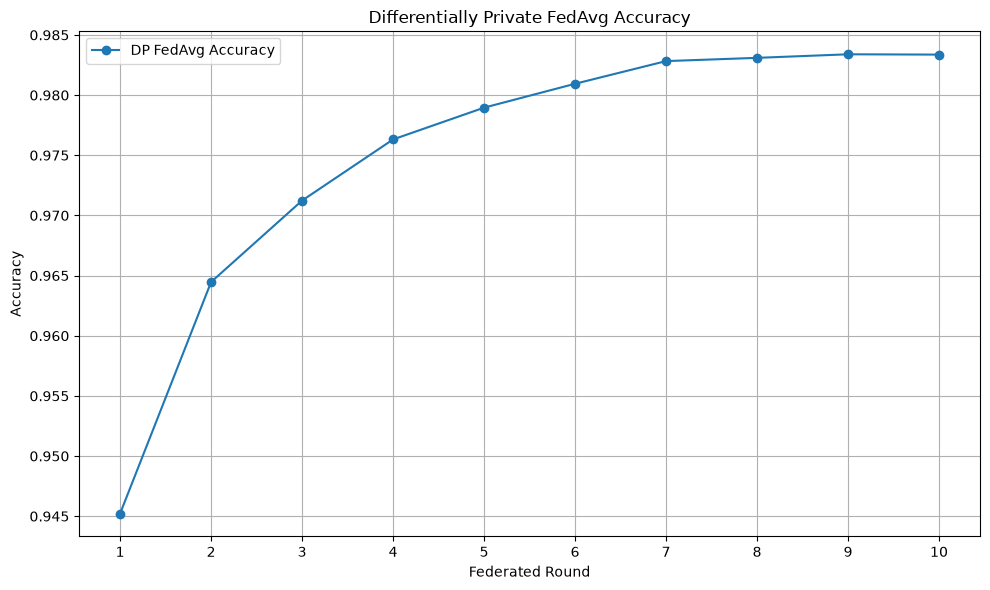

Saved: ..\results\dp_federated_learning_accuracy.png


In [69]:
# ============================================================
# DP LEARNING CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    dp_results_df["round"],
    dp_results_df["accuracy"],
    marker="o",
    label="DP FedAvg Accuracy"
)

plt.xlabel("Federated Round")
plt.ylabel("Accuracy")
plt.title("Differentially Private FedAvg Accuracy")
plt.xticks(dp_results_df["round"])
plt.grid(True)
plt.legend()
plt.tight_layout()

dp_plot_path = results_dir / "dp_federated_learning_accuracy.png"

plt.savefig(
    dp_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", dp_plot_path)